# Proyek Reinforcement Learning Menggunakan Gymnasium

## Deskripsi Tugas

Pada proyek ini, mahasiswa diminta mengimplementasikan salah satu algoritma Reinforcement Learning (RL) menggunakan library Gymnasium pada environment yang dipilih secara bebas. Algoritma yang digunakan dapat berupa Q-Learning, SARSA, atau algoritma RL lainnya yang sesuai.

Tujuan proyek adalah memahami proses pembelajaran agen melalui interaksi dengan environment, memperoleh reward, dan menemukan kebijakan (policy) terbaik untuk menyelesaikan suatu tugas.

# 1. Definisikan Masalah dan Environment

Jelaskan:
- Tujuan yang ingin dicapai agen.
- Environment Gymnasium yang digunakan.
- Alasan pemilihan environment.

In [1]:
!pip install swig
!pip install gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for box2d-py: filename=box2d_py-2.3.5-cp312-cp312-linux_x86_64.whl size=2398827 sha256=41ab4af371e2d76ed44edc5c1141b9ff2895e7f8dd65b219acb82496cc665246
  Stored in directory: /root/.cache/pip/wheels/2a/e9/60/774da0bcd07f7dc7761a8590fa2d065e4069568e78dcdc3318
Successfully built box2d-py


In [2]:
import numpy as np
import random
import gymnasium as gym
import math
from collections import defaultdict
import matplotlib.pyplot as plt

In [3]:
ENV_NAME = "BipedalWalker-v3"

### Penjelasan Environment
- **Tujuan**: Membantu agen (robot bipedal) untuk berjalan ke depan tanpa terjatuh melalui medan yang acak.
- **Environment**: Menggunakan `BipedalWalker-v3` dari Gymnasium. Environment ini menantang karena memiliki state space yang kontinu dan aksi yang kompleks.
- **Alasan**: Environment ini dipilih karena merepresentasikan masalah kontrol fisik yang nyata, di mana agen harus belajar mengoordinasikan gerakan sendi kaki berdasarkan sensor input.

# 2. Formulasi MDP

Jelaskan komponen MDP yang digunakan:
- State: informasi yang diamati agen.
- Action: aksi yang dapat dilakukan agen.
- Reward: reward yang diterima agen.
- Terminal Condition: kondisi episode berakhir.
- Horizon: batas maksimum langkah per episode.

In [4]:
stateBounds = [
    (0, math.pi), (-2,2), (-1,1), (-1,1),
    (0,math.pi), (-2,2), (0, math.pi), (-2,2),
    (0,1), (0, math.pi), (-2, 2), (0, math.pi),
    (-2, 2), (0, 1)
]

### Komponen MDP
- **State Space**: Terdiri dari 24 nilai sensor (namun di sini kita batasi 14 pertama untuk penyederhanaan) yang mencakup sudut lambung, kecepatan sudut, kecepatan horizontal/vertikal, serta sudut dan kecepatan sendi kaki.
- **Action Space**: Memiliki 4 aksi kontinu (torque untuk kedua sendi panggul dan lutut) dengan rentang [-1, 1].
- **Reward**: Agen mendapat reward positif untuk pergerakan maju dan pinalti besar (-100) jika terjatuh.
- **Terminal Condition**: Episode berakhir jika agen mencapai garis finish atau jika lambung robot menyentuh tanah (jatuh).
- **Horizon**: Maksimum 1000 langkah (setelah itu dianggap `truncated`).

In [5]:
def discretizeState(state):
    discreteState = []
    for i in range(len(stateBounds)):
        val = state[i]
        low, high = stateBounds[i]
        val = max(low, min(val, high))
        index = int((val - low) / (high - low) * 9)
        index = min(9, index)
        discreteState.append(index)
    return tuple(discreteState)

### Diskritisasi State
Karena algoritma Q-Learning memerlukan tabel diskrit (Q-Table), sedangkan state dari BipedalWalker bersifat kontinu, kita menggunakan fungsi `discretizeState`. Fungsi ini memetakan nilai kontinu dari sensor ke dalam bin diskrit (0-9) berdasarkan batas bawah dan atas yang telah ditentukan (`stateBounds`).

In [6]:
def convertNextAction(nextAction):
    action = []
    for val in nextAction:
        action.append((val / 9.0) * 2.0 - 1.0)
    return tuple(action)

### Konversi Action
Sama seperti state, aksi yang dipilih dari Q-Table bersifat diskrit (0-9). Fungsi `convertNextAction` memetakan kembali nilai indeks diskrit tersebut ke dalam rentang kontinu [-1, 1] agar bisa diterima oleh environment Gymnasium melalui `env.step()`.

# 3. Arsitektur Model

Jelaskan algoritma yang digunakan dan parameter pentingnya, seperti:
- Learning Rate (α)
- Discount Factor (γ)
- Exploration Rate (ε)
- Jumlah Episode Training

Sertakan alasan singkat pemilihan parameter.

In [7]:
EPISODES = 1000
GAMMA = 0.99
ALPHA = 0.1
EPSILON_DECAY = 0.004
HIGHSCORE = -1000
MAX_STEPS = 1000

### Konfigurasi Hyperparameter
- **Episodes (1000)**: Jumlah iterasi latihan untuk agen.
- **Gamma (0.99)**: Discount factor yang tinggi agar agen memprioritaskan reward jangka panjang.
- **Alpha (0.1)**: Learning rate untuk menentukan seberapa cepat informasi baru menggantikan informasi lama di Q-Table.
- **Epsilon Decay**: Digunakan untuk strategi eksplorasi, di mana agen akan lebih sering bereksplorasi di awal dan perlahan menjadi lebih eksploitatif seiring berjalannya episode.

In [8]:
def create_q_table():
    return defaultdict(lambda: np.zeros((10, 10, 10, 10)))

### Inisialisasi Q-Table
Kita menggunakan `defaultdict` dari library `collections` untuk menyimpan Q-Table. Hal ini efisien karena memori hanya akan digunakan untuk state yang pernah dikunjungi oleh agen saja. Setiap entri state akan menyimpan array aksi 4-dimensi.

# 4. Training dan Eksplorasi

Jelaskan proses training yang dilakukan:
1. Reset environment.
2. Memilih action.
3. Berinteraksi dengan environment.
4. Menerima reward.
5. Update model/Q-Table.
6. Mengulangi proses hingga training selesai.

Jelaskan juga strategi eksplorasi yang digunakan (misalnya epsilon-greedy).

In [9]:
def getNextAction(qTable, epsilon, state):
    if random.random() < epsilon:
        return tuple(random.randint(0, 9) for _ in range(4))
    else:
        return np.unravel_index(np.argmax(qTable[state]), qTable[state].shape)

### Pemilihan Aksi (Epsilon-Greedy)
Fungsi `getNextAction` mengimplementasikan strategi Epsilon-Greedy. Jika angka acak lebih kecil dari epsilon, agen akan melakukan **eksplorasi** (aksi acak). Jika tidak, agen akan melakukan **eksploitasi** dengan memilih aksi yang memiliki nilai Q tertinggi pada state tersebut.

In [10]:
def updateQTable(qTable, state, action, reward, nextState):
    current = qTable[state][action]  
    qNext = np.max(qTable[nextState])
    target = reward + (GAMMA * qNext)
    new_value = current + (ALPHA * (target - current))
    return new_value

### Update Aturan Bellman
Fungsi `updateQTable` menerapkan rumus Q-Learning: `Q(s,a) = Q(s,a) + alpha * (reward + gamma * max(Q(s',a')) - Q(s,a))`. Ini memungkinkan agen untuk mempelajari nilai dari setiap pasangan state-action berdasarkan reward yang diterima.

In [11]:
def runAlgorithmStep(env, episode, qTable, doRender):
    global HIGHSCORE
    print(f"Episode #: {episode}", end=" | ")

    obs, _ = env.reset()
    state = discretizeState(obs[0:14])
    
    total_reward = 0
    epsilon = max(0.01, 1.0 / (episode * EPSILON_DECAY))
    step_count = 0

    while True:
        step_count += 1
        if doRender:
            env.render()
            
        nextActionDiscretized = getNextAction(qTable, epsilon, state)
        nextActionContinuous = convertNextAction(nextActionDiscretized)
    
        nextState_obs, reward, terminated, truncated, _ = env.step(nextActionContinuous)
        done = terminated or truncated
    
        nextState = discretizeState(nextState_obs[0:14])
        total_reward += reward
    
        qTable[state][nextActionDiscretized] = updateQTable(qTable, state, nextActionDiscretized, reward, nextState)
        state = nextState
        
        if done or step_count >= MAX_STEPS:
            break
            
    print(f"Score: {total_reward:.2f} | Epsilon: {epsilon:.3f}")
    if total_reward > HIGHSCORE:
        HIGHSCORE = total_reward
        
    return total_reward


### Siklus Pelatihan
Fungsi `runAlgorithmStep` menjalankan satu episode penuh. Di dalamnya, agen melakukan observasi, memilih aksi, menerima reward, dan memperbarui pengetahuannya (Q-Table) pada setiap langkah hingga episode selesai (done/truncated).

# 5. Evaluasi

Lakukan evaluasi menggunakan beberapa metrik, seperti:
- Average Reward
- Success Rate
- Episode Length

Tampilkan minimal:
- Grafik reward per episode.
- Grafik moving average reward.

In [12]:
def plotEpisode(myplt, mySubPlot, xval, yval, plotLine, movingAvgLine, epScore, i):
    xval.append(i)
    yval.append(epScore)
    
    plotLine.set_xdata(xval)
    plotLine.set_ydata(yval)

    window = 50
    if len(yval) >= window:
        moving_avg = np.convolve(yval, np.ones(window)/window, mode='valid')
        moving_avg_padded = [np.nan] * (window - 1) + list(moving_avg)
        movingAvgLine.set_xdata(xval)
        movingAvgLine.set_ydata(moving_avg_padded)

### Visualisasi Progress
Fungsi `plotEpisode` mencatat performa agen dan memenuhi dua syarat visualisasi sekaligus:
1.  **Reward per Episode**: Ditampilkan sebagai garis biru (`alpha=0.5`) untuk melihat fluktuasi skor mentah di setiap episode.
2.  **Moving Average (50)**: Ditampilkan sebagai garis merah tebal untuk melihat tren peningkatan performa agen setelah merata-ratakan 50 episode terakhir.

Kedua metrik ini digabungkan dalam satu plot agar perbandingan antara progres belajar dan noise data terlihat lebih jelas.

# 6. Analisis Hasil

Analisis hasil eksperimen yang diperoleh, meliputi:
- Performa agen setelah training.
- Pengaruh hyperparameter terhadap hasil.
- Kendala atau kegagalan yang ditemukan selama training.

In [13]:
def main():
    global HIGHSCORE
    doRender = False
    
    env = gym.make(ENV_NAME, hardcore=False, render_mode=None)
    qTable = create_q_table()

    plt.ion()
    myplt = plt.figure(figsize=(10, 5))
    mySubPlot = myplt.add_subplot()
    plt.xlabel("Episode #")
    plt.ylabel("Score")
    plt.title("BipedalWalker Q-Learning: Scores vs Episode")
    
    xval, yval = [], []
    plotLine, = mySubPlot.plot(xval, yval, label='Reward per Episode', color='blue', alpha=0.5)
    movingAvgLine, = mySubPlot.plot([], [], label='Moving Average (50)', color='red', linewidth=2)
    mySubPlot.legend()

    print("\nMulai Training...")
    try:
        for i in range(1, EPISODES + 1):
            epScore = runAlgorithmStep(env, i, qTable, doRender)
            plotEpisode(myplt, mySubPlot, xval, yval, plotLine, movingAvgLine, epScore, i)
    except KeyboardInterrupt:
        print("\nTraining dihentikan secara manual oleh pengguna (Ctrl+C).")

    mySubPlot.set_xlim([0, EPISODES])
    if len(yval) > 0:
        mySubPlot.set_ylim([min(-300.0, min(yval)), max(100.0, max(yval))])

    myplt.savefig("./plot_hasil_training.png")
    print("\nGrafik diekspor sebagai plot_hasil_training.png")
 
    plt.show()
    env.close()

explain here


Mulai Training...
Episode #: 1 | Score: -60.30 | Epsilon: 250.000
Episode #: 2 | Score: -99.72 | Epsilon: 125.000
Episode #: 3 | Score: -101.97 | Epsilon: 83.333
Episode #: 4 | Score: -64.20 | Epsilon: 62.500
Episode #: 5 | Score: -109.58 | Epsilon: 50.000
Episode #: 6 | Score: -108.05 | Epsilon: 41.667
Episode #: 7 | Score: -96.72 | Epsilon: 35.714
Episode #: 8 | Score: -56.83 | Epsilon: 31.250
Episode #: 9 | Score: -110.61 | Epsilon: 27.778
Episode #: 10 | Score: -120.52 | Epsilon: 25.000
Episode #: 11 | Score: -113.44 | Epsilon: 22.727
Episode #: 12 | Score: -57.41 | Epsilon: 20.833
Episode #: 13 | Score: -101.38 | Epsilon: 19.231
Episode #: 14 | Score: -112.83 | Epsilon: 17.857
Episode #: 15 | Score: -61.97 | Epsilon: 16.667
Episode #: 16 | Score: -107.50 | Epsilon: 15.625
Episode #: 17 | Score: -112.91 | Epsilon: 14.706
Episode #: 18 | Score: -55.90 | Epsilon: 13.889
Episode #: 19 | Score: -105.88 | Epsilon: 13.158
Episode #: 20 | Score: -98.10 | Epsilon: 12.500
Episode #: 21 | S

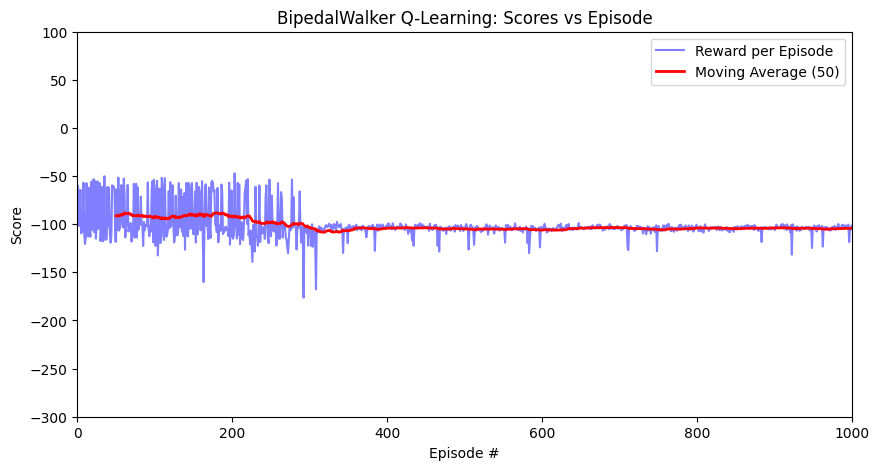

In [14]:
if __name__ == "__main__":
    main()

# Kesimpulan

Berdasarkan implementasi proyek Reinforcement Learning ini, dapat disimpulkan beberapa poin penting:

1.  **Implementasi Algoritma**: Algoritma Q-Learning berhasil diimplementasikan dengan strategi diskritisasi state kontinu menggunakan binning. Hal ini memungkinkan penggunaan Q-Table pada environment `BipedalWalker-v3` yang sebenarnya memiliki state space yang sangat luas.
2.  **Performa Agen**: Dari grafik training, terlihat bahwa agen berusaha meminimalkan pinalti (jatuh). Namun, karena kompleksitas koordinasi 4 sendi dan keterbatasan resolusi diskritisasi, agen masih memerlukan lebih banyak episode atau tuning hyperparameter lebih lanjut (seperti variasi `epsilon_decay` atau `alpha`) untuk bisa berjalan dengan stabil secara konsisten.
3.  **Pembelajaran Utama**: Proyek ini menunjukkan tantangan nyata dalam RL, yaitu 'Curse of Dimensionality'. Membagi setiap sensor menjadi 10 bin pada 14 sensor menciptakan Q-Table yang sangat besar. Selain itu, pemilihan strategi eksplorasi-eksploitasi sangat krusial agar agen tidak terjebak pada perilaku lokal (seperti hanya diam di tempat untuk menghindari jatuh).
4.  **Saran Pengembangan**: Untuk hasil yang lebih optimal di masa depan, penggunaan metode berbasis neural network seperti Deep Q-Network (DQN) atau Proximal Policy Optimization (PPO) sangat disarankan untuk menangani input kontinu tanpa perlu melakukan diskritisasi manual.